# Can Unsupervised Learning Discover Clinically Meaningful Thyroid Cancer Patient Subgroups?

## Introduction

The objective of this notebook is to investigate whether thyroid cancer patients naturally form clinically meaningful subgroups using unsupervised learning techniques. Unlike supervised learning, where models learn from labeled outcomes, clustering algorithms identify hidden structures within the data without access to recurrence information. This allows us to explore whether patients with similar clinicopathologic characteristics naturally group together.

### Research Question

> Can clustering algorithms identify clinically meaningful subgroups of thyroid cancer patients using clinicopathologic characteristics without access to recurrence information?

### Datasets: Two preprocessed feature sets will be investigated.

- Feature Set A: Baseline clinicopathologic characteristics.
- Feature Set B: Baseline clinicopathologic characteristics together with treatment response.

> The resulting cluster structures will be compared to evaluate the influence of post-treatment information on patient subgroup discovery.

### - Import Libraries

In [1]:
# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"

# Data handling & Visualization
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Evaluation metics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, \
    adjusted_rand_score, normalized_mutual_info_score

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



### - Load datasets

In [2]:
X_A = pd.read_csv(DATA_DIR / "feature_set_A.csv")
X_B = pd.read_csv(DATA_DIR / "feature_set_B.csv")

# External validation only
y = pd.read_csv(DATA_DIR / "recurred.csv")

In [4]:
X_A.head(5)

,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,...,nom__Adenopathy_Right,nom__Pathology_Follicular,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage
0,-0.923305,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
1,-0.460609,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
2,-0.725007,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
3,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
4,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0


In [5]:
X_B.head(5)

,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,...,nom__Pathology_Follicular,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage,ord__Response
0,-0.923305,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0
1,-0.460609,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
2,-0.725007,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
3,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
4,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0


### 1) Fit the algorithms on sets and Predict

In [3]:
def clustering_algorithms(X, n_clusters=3, eps=1.5, min_samples=5, n_components=3, RANDOM_STATE=42):
    # A dict of clustring algorithms
    clustering_algo = {
        "KMeans": KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE),
        "DBSCAN": DBSCAN(eps=eps, min_samples=min_samples),
        "AgglomerativeClustering": AgglomerativeClustering(n_clusters=n_clusters),
        "GaussianMixture": GaussianMixture(n_components=n_components, random_state=RANDOM_STATE)
    }

    # Fit, Predict and Store the Results
    algo_clusters = {f'{name} Clusters': algo.fit_predict(X) for name, algo in clustering_algo.items()}
    
    return algo_clusters, clustering_algo


In [4]:
# Apply models on the sets
X_A_clusters, clt_algo = clustering_algorithms(X_A)
X_B_clusters, clt_algo = clustering_algorithms(X_B)

### 2) Internal Evaluation

In [5]:
def internal_evaluation(X, clusters):
    # Calculate internal evaluation metrics
    silhouette = silhouette_score(X, clusters)
    db = davies_bouldin_score(X, clusters)
    ch = calinski_harabasz_score(X, clusters)

    return silhouette, db, ch


In [6]:
def evaluation_results(clt_algo, X_A_clusters, X_B_clusters):
    # A list to store results
    results = []
    
    for name in clt_algo.keys():

        clusters = f"{name} Clusters"

        # Feature Set A
        s, db, ch = internal_evaluation(X_A, X_A_clusters[clusters])

        results.append({
            "Algorithm": name,
            "Feature Set": "A",
            "Silhouette": s,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch
        })

        # Feature Set B
        s, db, ch = internal_evaluation(X_B, X_B_clusters[clusters])

        results.append({
            "Algorithm": name,
            "Feature Set": "B",
            "Silhouette": s,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch
        })

    return pd.DataFrame(results)


evaluation_df = evaluation_results(
    clt_algo,
    X_A_clusters,
    X_B_clusters
)

evaluation_df


,Algorithm,Feature Set,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,A,0.193692,1.498592,101.711580
1,KMeans,B,0.157221,1.753403,104.299514
2,DBSCAN,A,0.138710,2.421144,52.336145
3,DBSCAN,B,0.071328,2.108087,32.895007
4,AgglomerativeClustering,A,0.222436,1.565213,97.940947
5,AgglomerativeClustering,B,0.252298,1.503206,103.252122
6,GaussianMixture,A,0.126193,2.352071,78.906164
7,GaussianMixture,B,0.142910,2.281499,76.068014


#### - Plot Manual Internal Evaluation

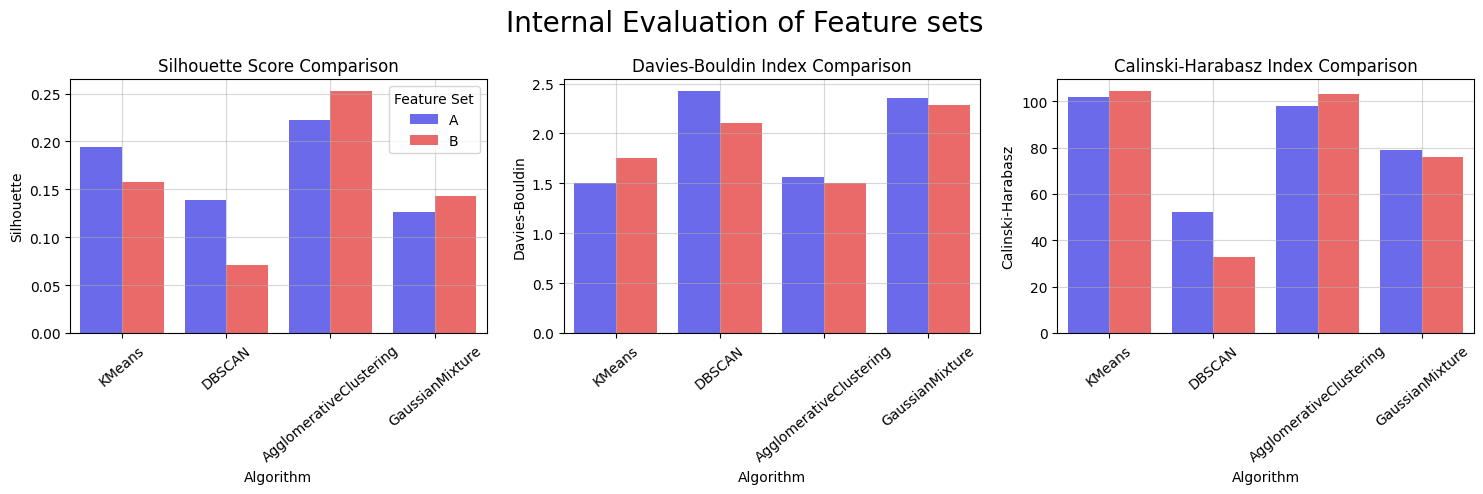

In [7]:
# ----------------------------------------------------
# Clustering Evaluation Metrics Comparison - Bar Plot
# ----------------------------------------------------

def bar_plot_eval_results(evaluation_df, metrics, titles):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, metric, title in zip(axes, metrics, titles):
        sns.barplot(
            data=evaluation_df,
            x="Algorithm",
            y=metric,
            hue="Feature Set",
            palette="seismic",
            ax=ax
        )

        ax.set_title(title)
        ax.grid(alpha=0.5)
        ax.tick_params(axis='x', rotation=40)

    # Show legend only once
    handles, labels = axes[0].get_legend_handles_labels()

    for ax in axes[1:]:
        ax.get_legend().remove()

    axes[0].legend(title="Feature Set")

    plt.suptitle("Internal Evaluation of Feature sets", fontsize=20)
    plt.tight_layout()
    plt.show()


metrics = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

titles = [
    "Silhouette Score Comparison",
    "Davies-Bouldin Index Comparison",
    "Calinski-Harabasz Index Comparison"
]

bar_plot_eval_results(evaluation_df, metrics, titles)

### 3) Build up results and store
- Adding cluster column to the set
- Counting the number of samples in each cluster
- Calculating clusters characteristics

In [8]:
def resulting(X, clusters):
    # Make copy of the feature set
    results = X.copy()
    # Add clusters to the set
    results["Cluster"] = clusters
    # Count number of samples in each cluster
    sample_counts = results["Cluster"].value_counts().sort_index()
    # Return clusters characteristics
    cluster_char = results.groupby("Cluster").mean(numeric_only=True)

    return results, sample_counts, cluster_char



In [9]:
def apply_resulting(clt_algo, X_A_clusters, X_B_clusters):

    # Store complete result tables
    results = {}

    # Store sample counts
    sample_counts_rows = []

    # Store cluster characteristics
    cluster_char_rows = []

    for name in clt_algo.keys():

        clusters = f"{name} Clusters"

        # ==========================
        # Feature Set A
        # ==========================

        res_A, count_A, char_A = resulting(X_A, X_A_clusters[clusters])

        results[f"{name}_A"] = res_A

        count_df_A = count_A.reset_index()
        count_df_A.columns = ["Cluster", "Count"]
        count_df_A["Algorithm"] = name
        count_df_A["Feature Set"] = "A"

        sample_counts_rows.append(count_df_A)

        char_df_A = (
            char_A
            .reset_index()
            .melt(id_vars="Cluster",
                  var_name="Feature",
                  value_name="Mean")
        )

        char_df_A["Algorithm"] = name
        char_df_A["Feature Set"] = "A"

        cluster_char_rows.append(char_df_A)


        # ==========================
        # Feature Set B
        # ==========================

        res_B, count_B, char_B = resulting(X_B, X_B_clusters[clusters])

        results[f"{name}_B"] = res_B

        count_df_B = count_B.reset_index()
        count_df_B.columns = ["Cluster", "Count"]
        count_df_B["Algorithm"] = name
        count_df_B["Feature Set"] = "B"

        sample_counts_rows.append(count_df_B)

        char_df_B = (
            char_B
            .reset_index()
            .melt(id_vars="Cluster",
                  var_name="Feature",
                  value_name="Mean")
        )

        char_df_B["Algorithm"] = name
        char_df_B["Feature Set"] = "B"

        cluster_char_rows.append(char_df_B)


    sample_counts_df = pd.concat(sample_counts_rows, ignore_index=True)
    cluster_char_df = pd.concat(cluster_char_rows, ignore_index=True)

    return results, sample_counts_df, cluster_char_df


results, sample_counts_df, cluster_char_df = apply_resulting(
    clt_algo,
    X_A_clusters,
    X_B_clusters
)

### - Inspect results set

In [75]:
results["KMeans_A"].head() # Just a random peek

,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Focality_Multi-Focal,...,nom__Pathology_Follicular,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage,Cluster
0,-0.923305,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2
1,-0.460609,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2
2,-0.725007,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2
3,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2
4,1.390176,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2


### - Samples counts in each cluster

In [10]:
sample_counts_df

,Cluster,Count,Algorithm,Feature Set
0,0,246,KMeans,A
1,1,73,KMeans,A
2,2,61,KMeans,A
3,0,210,KMeans,B
4,1,82,KMeans,B
5,2,88,KMeans,B
6,-1,131,DBSCAN,A
7,0,216,DBSCAN,A
8,1,33,DBSCAN,A
9,-1,163,DBSCAN,B


In [11]:
# A helper function to get the sample counts of clusters in the corresponding set
def sample_per_algo_set(algo, feature_set):
    return (
        sample_counts_df.loc[
            (sample_counts_df["Algorithm"] == algo) &
            (sample_counts_df["Feature Set"] == feature_set)
        ]
        .sort_values("Cluster")
        .reset_index(drop=True)
    )

In [ ]:
sample_per_algo_set("KMeans", "A")  # Use

,Cluster,Count,Algorithm,Feature Set
0,0,246,KMeans,A
1,1,73,KMeans,A
2,2,61,KMeans,A


In [13]:
# --------------------------------------------------------------------------------------
# Plot sample counts in each cluster in the corresponding set using Bar and Pie plots
# --------------------------------------------------------------------------------------
def plot_sample_counts(algo):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    feature_sets = ["A", "B"]

    for row, feature_set in enumerate(feature_sets):

        df = sample_per_algo_set(algo, feature_set)

        clusters = df["Cluster"].astype(str)
        counts = df["Count"]

        # -------------------------
        # Bar Plot
        # -------------------------
        ax = axes[row, 0]

        bars = ax.bar(clusters, counts, color="firebrick")

        ax.set_title(f"{algo} - Feature Set {feature_set}")
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Number of Samples")
        ax.grid(alpha=0.5)

        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f"{int(bar.get_height())}",
                ha="center",
                va="bottom",
                fontsize=10
            )

        # -------------------------
        # Pie Chart
        # -------------------------
        ax = axes[row, 1]

        ax.pie(
        counts,
        labels=[f"{i}" for i in clusters],
        autopct="%1.1f%%",
        startangle=90,
        colors=["salmon", "mediumspringgreen", "royalblue", "khaki"],
        pctdistance=1.15,   # percentages farther out
        labeldistance=0.7   # labels closer to center
        )

        ax.set_title(f"{algo} - Feature Set {feature_set}")

    plt.suptitle(f"{algo} Sample Distribution", fontsize=16)

    plt.tight_layout()
    plt.show()

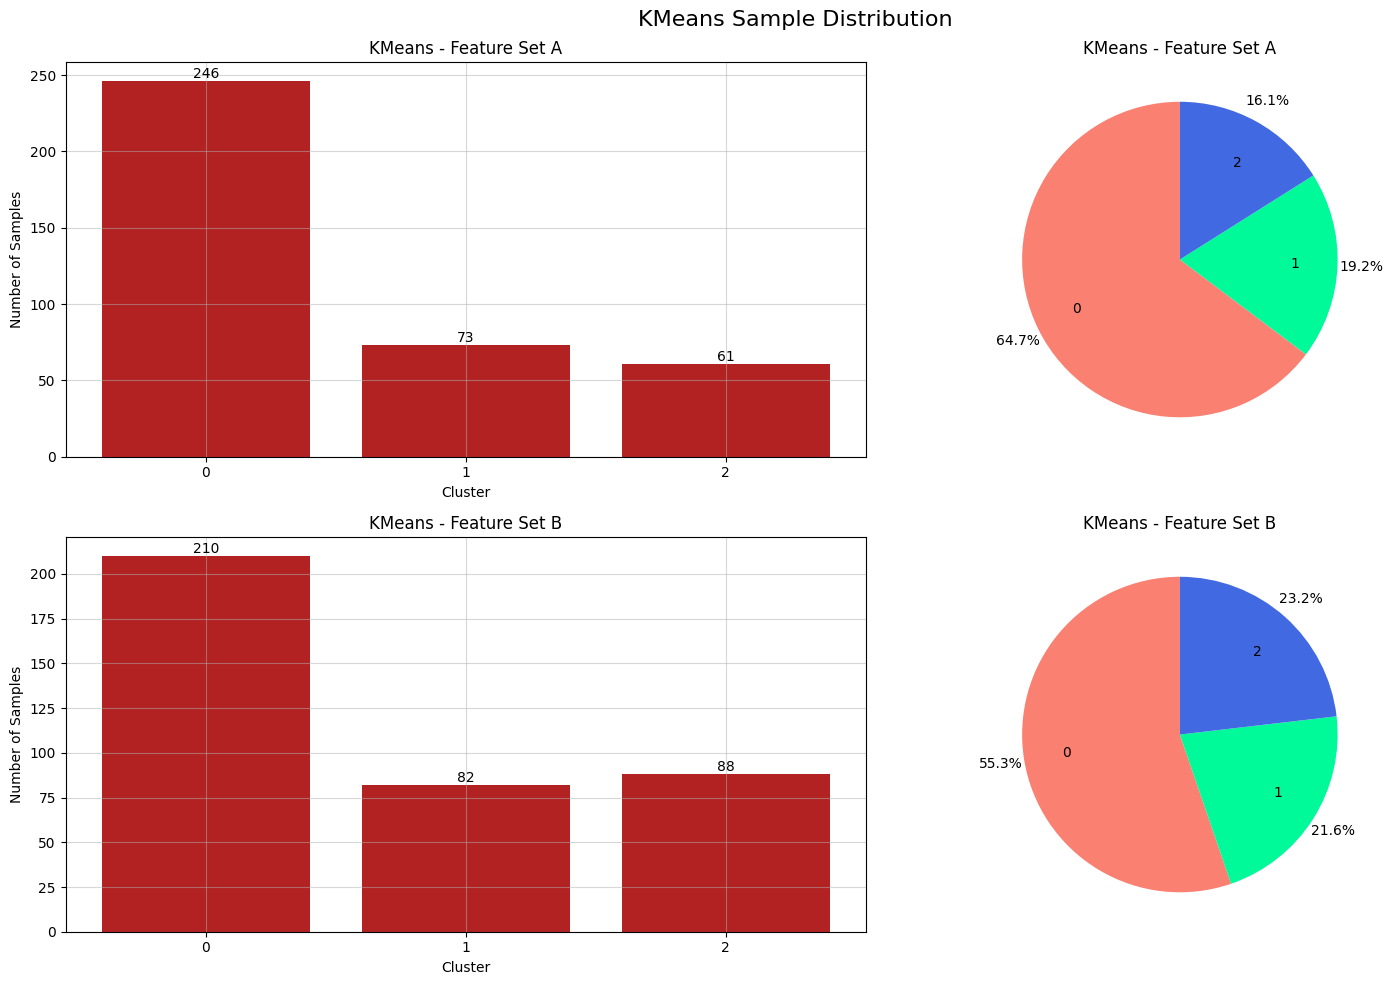

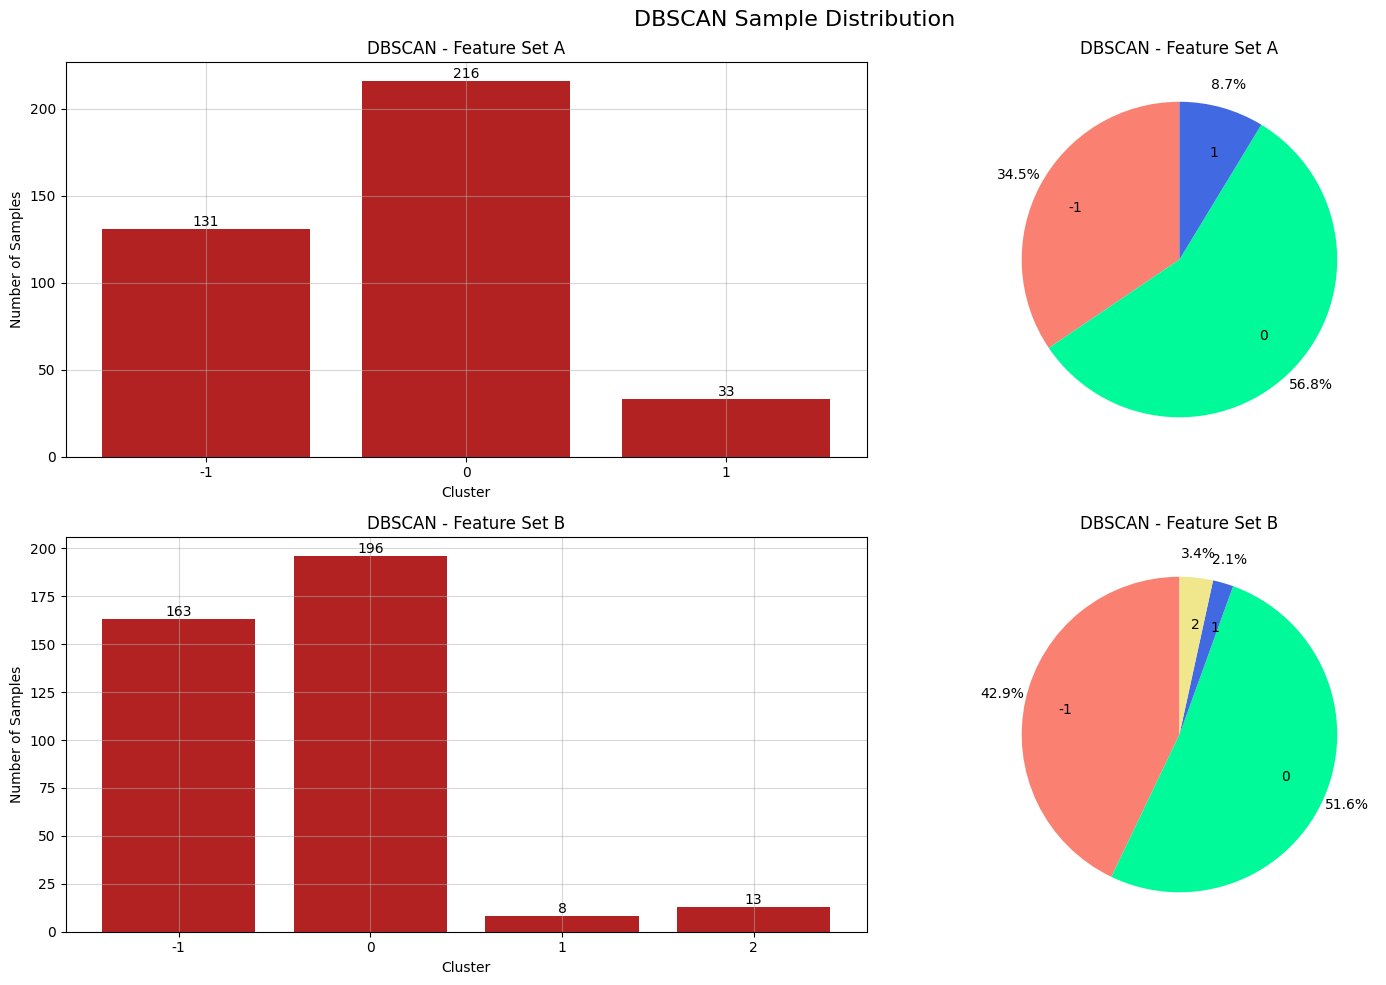

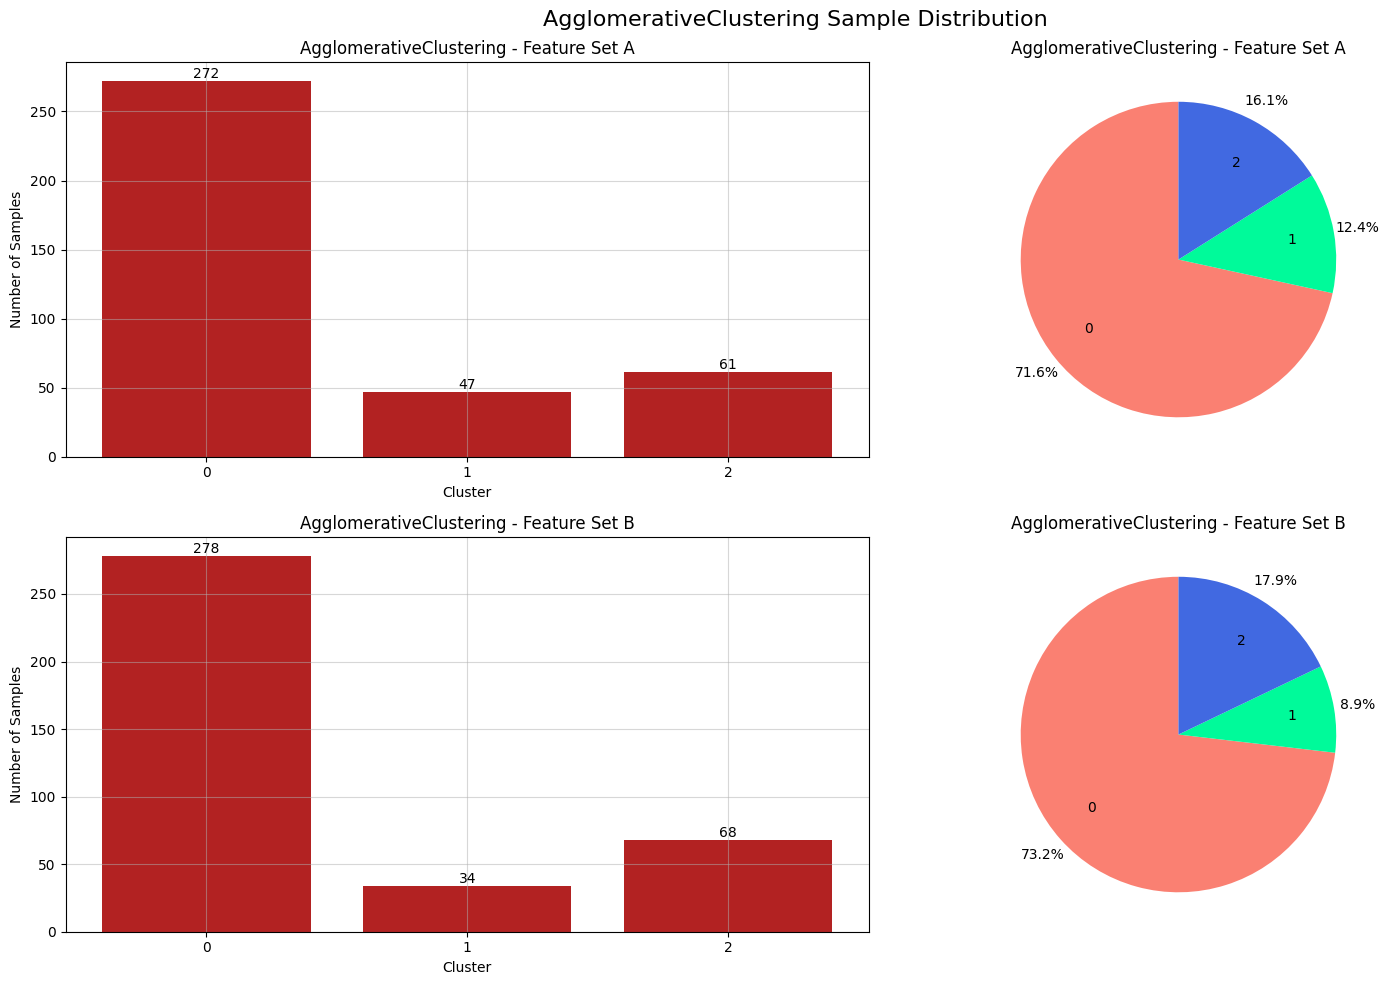

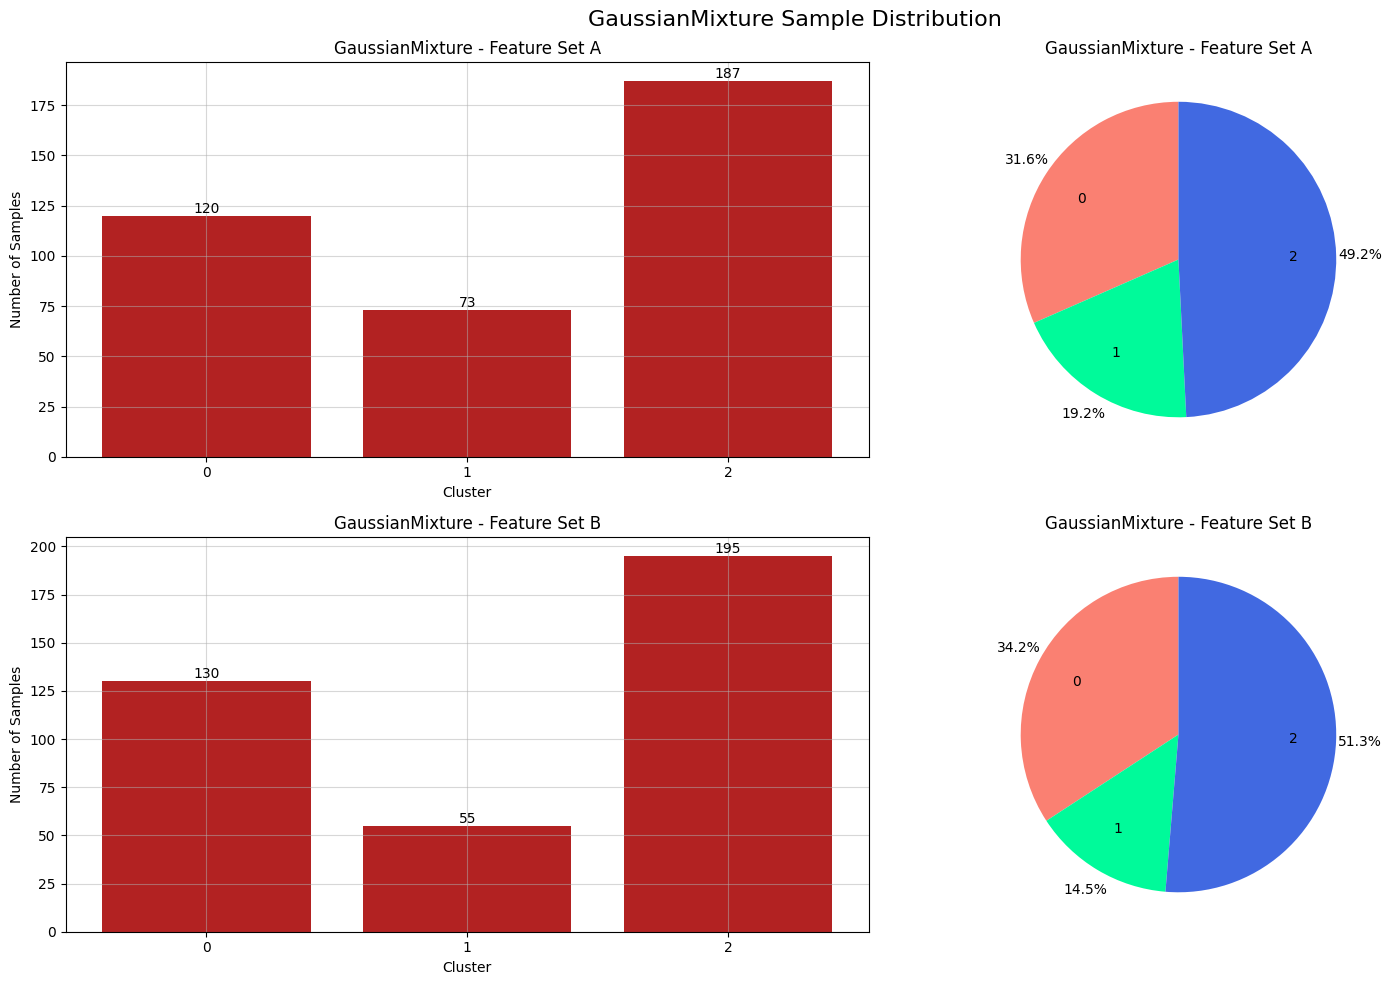

In [14]:
for algo in sample_counts_df["Algorithm"].unique():
    plot_sample_counts(algo)

### - Clusters Characteristics

In [15]:
cluster_char_df

,Cluster,Feature,Mean,Algorithm,Feature Set
0,0,con_num__Age,-0.358773,KMeans,A
1,1,con_num__Age,0.994485,KMeans,A
2,2,con_num__Age,0.256733,KMeans,A
3,0,bin__Gender_F,0.873984,KMeans,A
4,1,bin__Gender_F,0.520548,KMeans,A
...,...,...,...,...,...
908,1,ord__Stage,1.327273,GaussianMixture,B
909,2,ord__Stage,0.000000,GaussianMixture,B
910,0,ord__Response,1.784615,GaussianMixture,B
911,1,ord__Response,2.672727,GaussianMixture,B


In [16]:
cluster_char_df = cluster_char_df.rename(columns=rename_dict)

In [17]:
# A helper function to get the clusters characteristics in each algorithms and feature set
def clusterChar_per_algo_set(algo, feature_set):
    df = cluster_char_df[
        (cluster_char_df["Algorithm"] == algo) &
        (cluster_char_df["Feature Set"] == feature_set)
    ]

    return df.pivot(
        index="Cluster",
        columns="Feature",
        values="Mean"
    )

In [18]:
clusterChar_per_algo_set("KMeans", "A") # Peek

Feature,bin__Focality_Multi-Focal,bin__Focality_Uni-Focal,bin__Gender_F,bin__Gender_M,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Smoking_No,bin__Smoking_Yes,...,nom__Thyroid Function_Clinical Hyperthyroidism,nom__Thyroid Function_Clinical Hypothyroidism,nom__Thyroid Function_Euthyroid,nom__Thyroid Function_Subclinical Hyperthyroidism,nom__Thyroid Function_Subclinical Hypothyroidism,ord__M,ord__N,ord__Risk,ord__Stage,ord__T
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.264228,0.735772,0.873984,0.126016,0.995935,0.004065,0.959350,0.040650,0.939024,0.060976,...,0.044715,0.036585,0.878049,0.016260,0.024390,0.004065,0.390244,1.756098,0.008130,2.203252
1,0.863014,0.136986,0.520548,0.479452,0.917808,0.082192,0.821918,0.178082,0.561644,0.438356,...,0.054795,0.013699,0.849315,0.000000,0.082192,0.232877,1.479452,0.602740,1.246575,3.904110
2,0.131148,0.868852,0.918033,0.081967,1.000000,0.000000,0.918033,0.081967,0.967213,0.032787,...,0.081967,0.032787,0.836066,0.016393,0.032787,0.000000,0.065574,1.934426,0.000000,0.196721


In [22]:

def plot_cluster_char(cluster_char, title=""):

    cluster_char = cluster_char.rename(columns=rename_dict)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(18, 11),
        gridspec_kw={"height_ratios":[2.8,1]}
    )

    # --------------------
    # Bar Plot
    # --------------------
    cluster_char.T.plot(
        kind="bar",
        ax=axes[0],
        width=0.8
    )

    axes[0].set_title(f"{title} Cluster Characteristics")
    axes[0].set_ylabel("Mean Value")
    axes[0].set_xlabel("")
    axes[0].grid(alpha=0.5)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].legend(title="Cluster")

    # --------------------
    # Heatmap
    # --------------------
    sns.heatmap(
        cluster_char,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot_kws={"size":7},
        ax=axes[1]
    )

    axes[1].set_title("Heatmap")

    plt.tight_layout()
    plt.show()

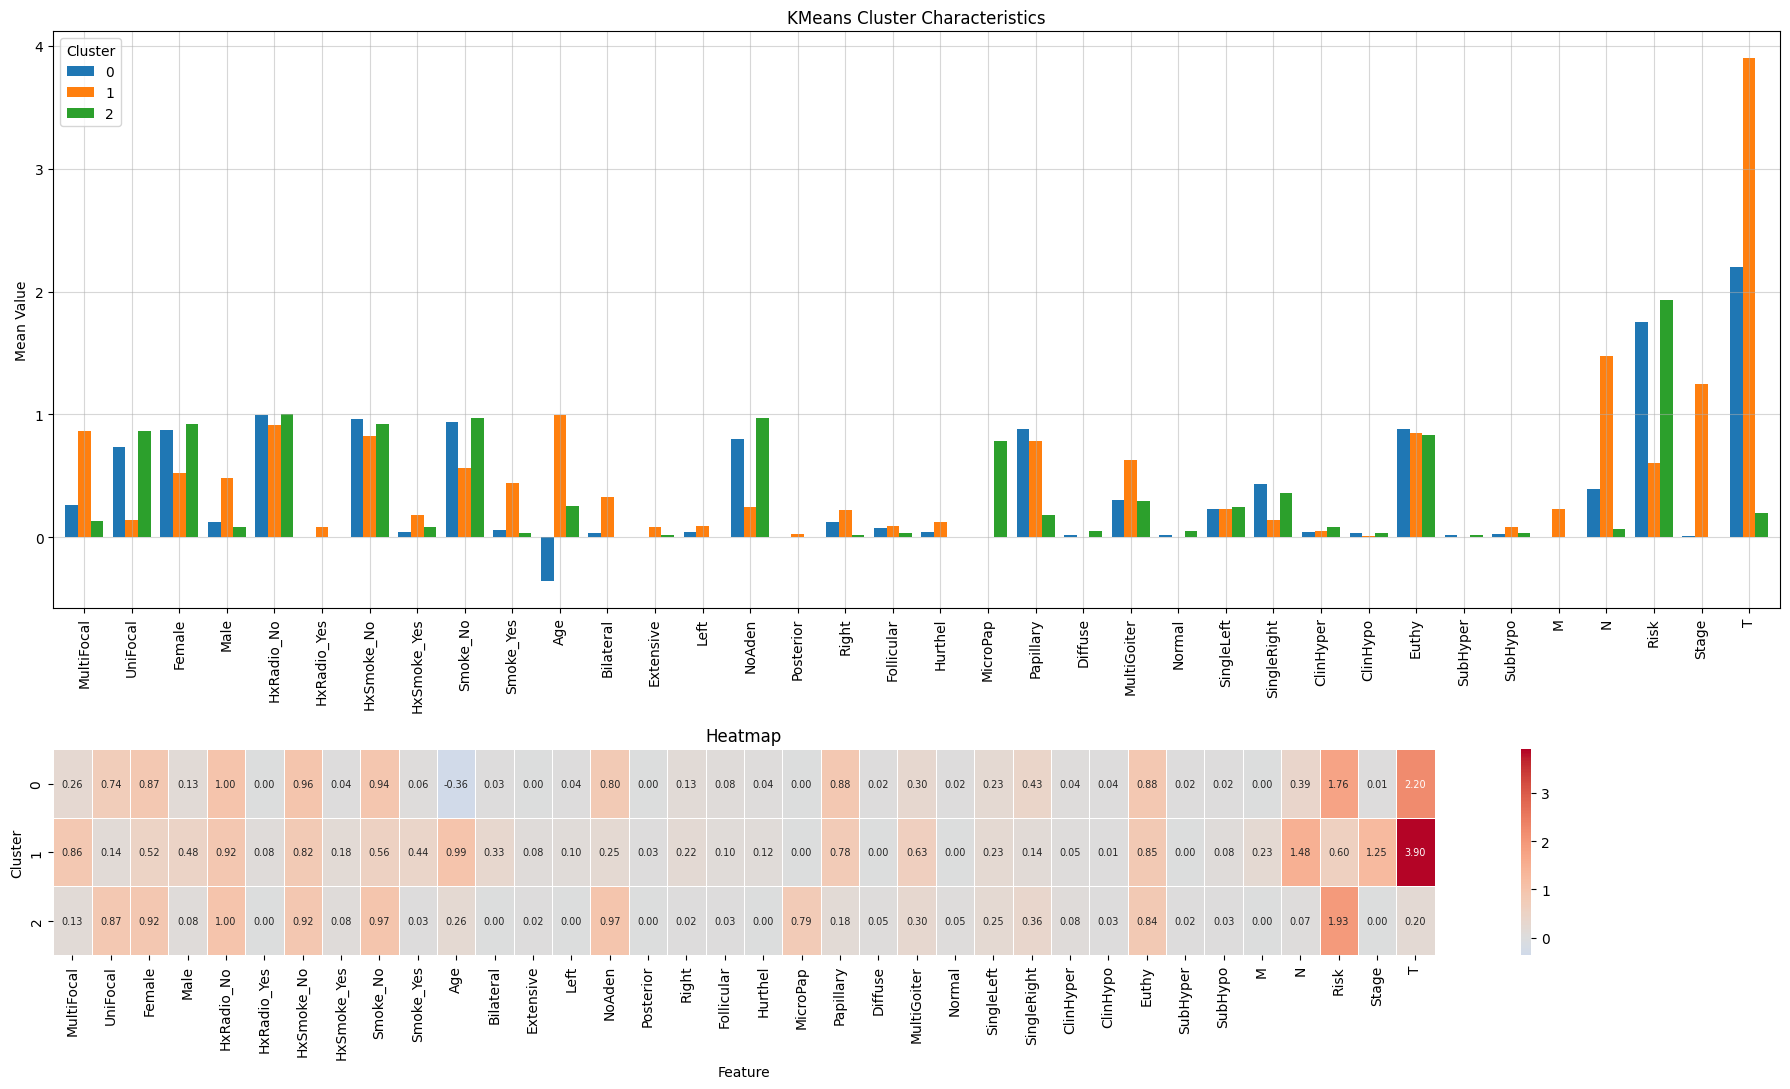

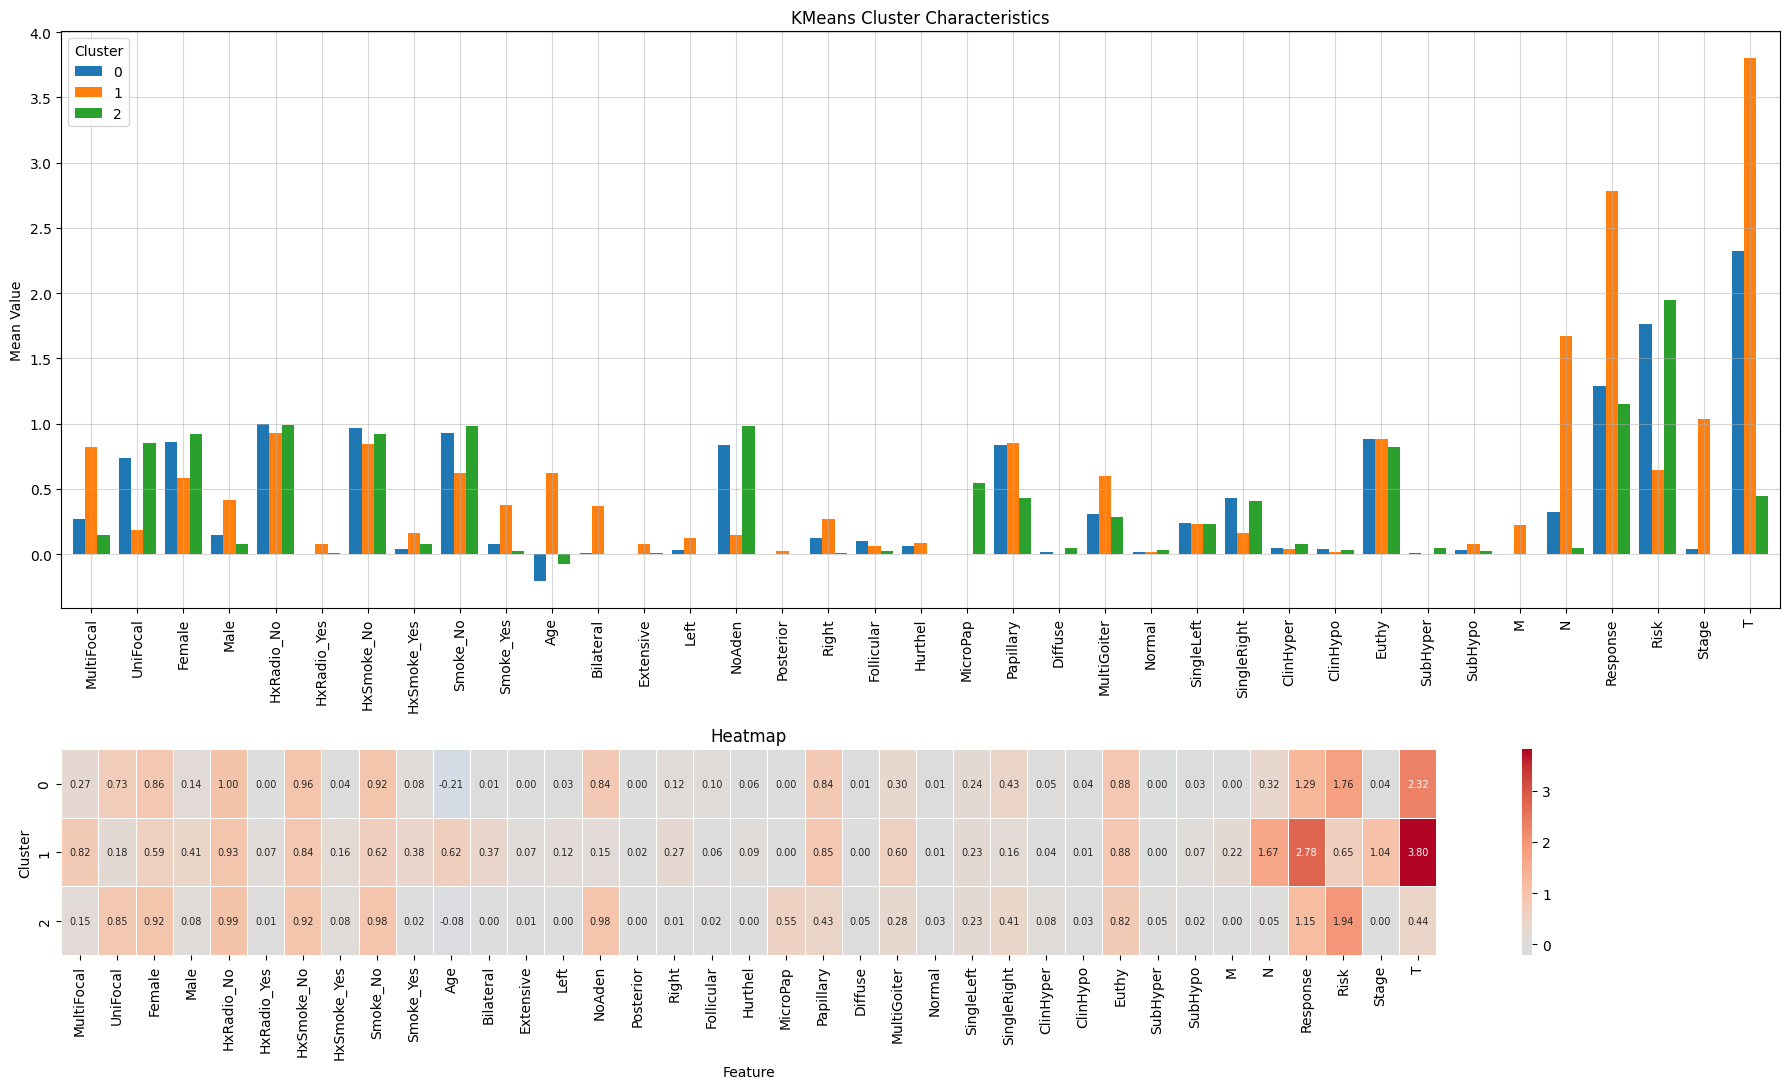

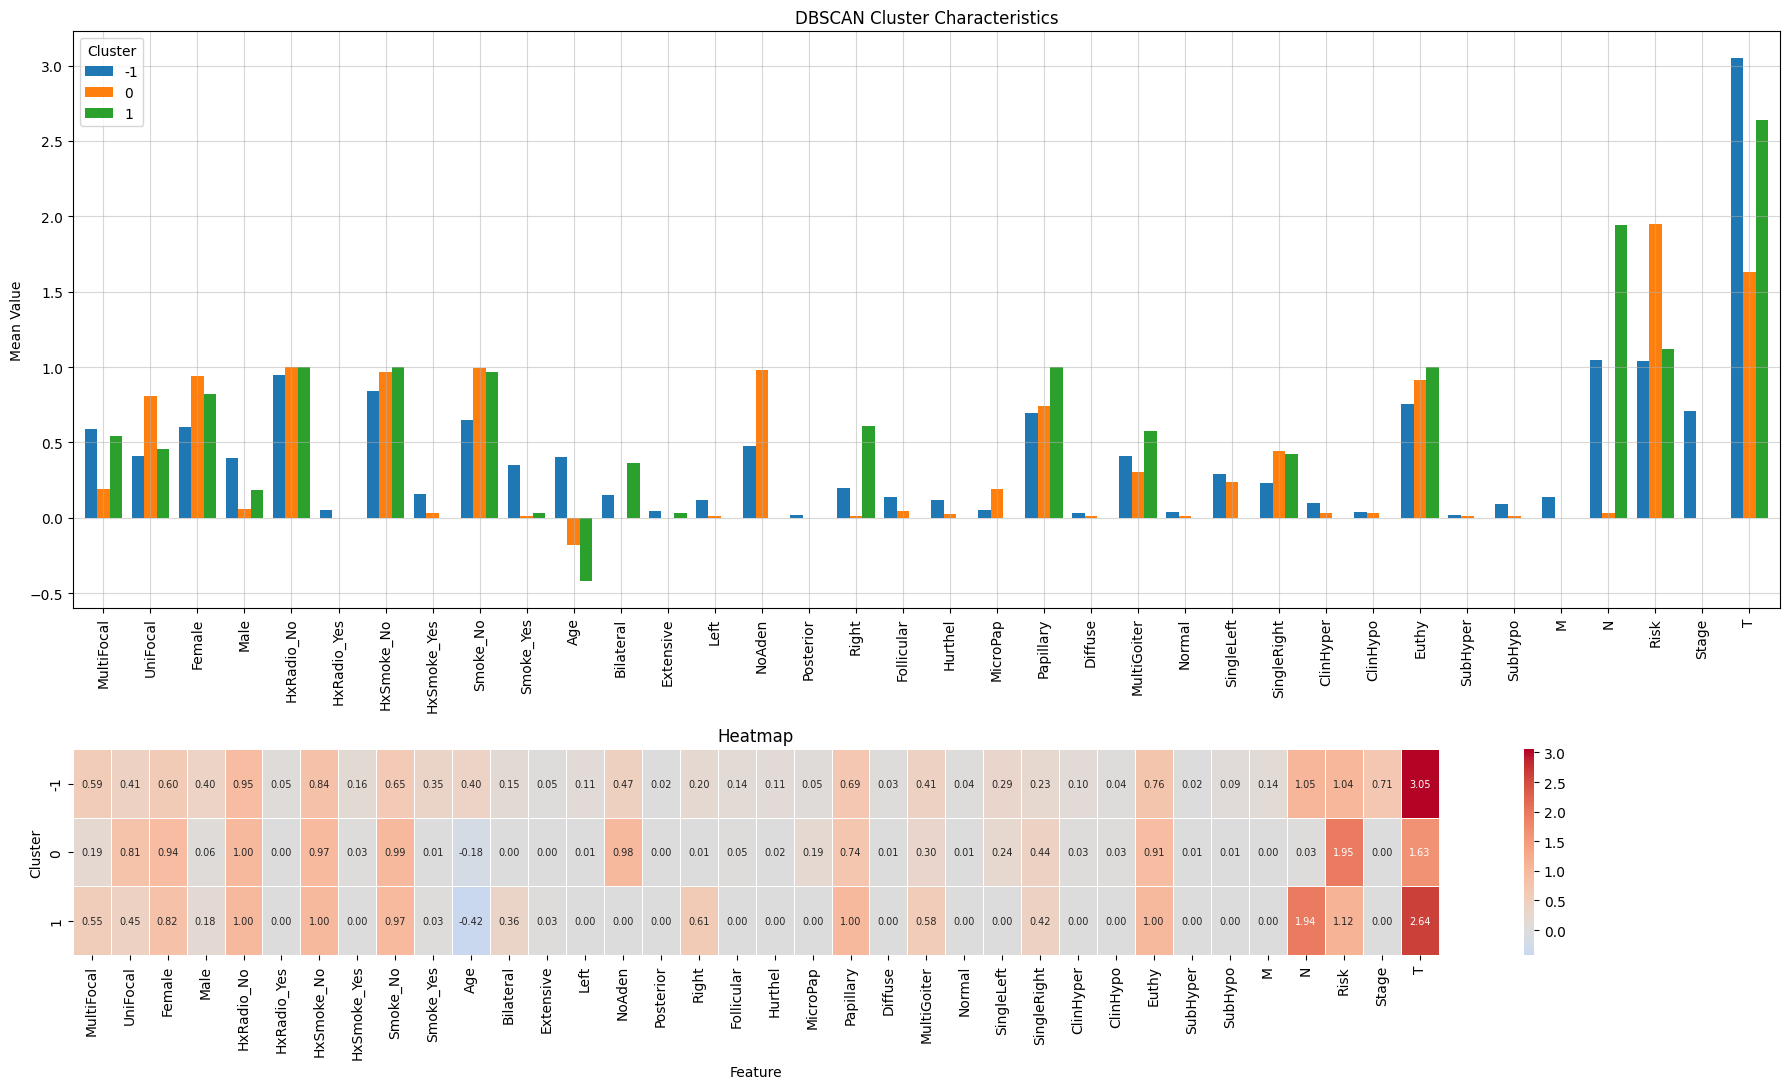

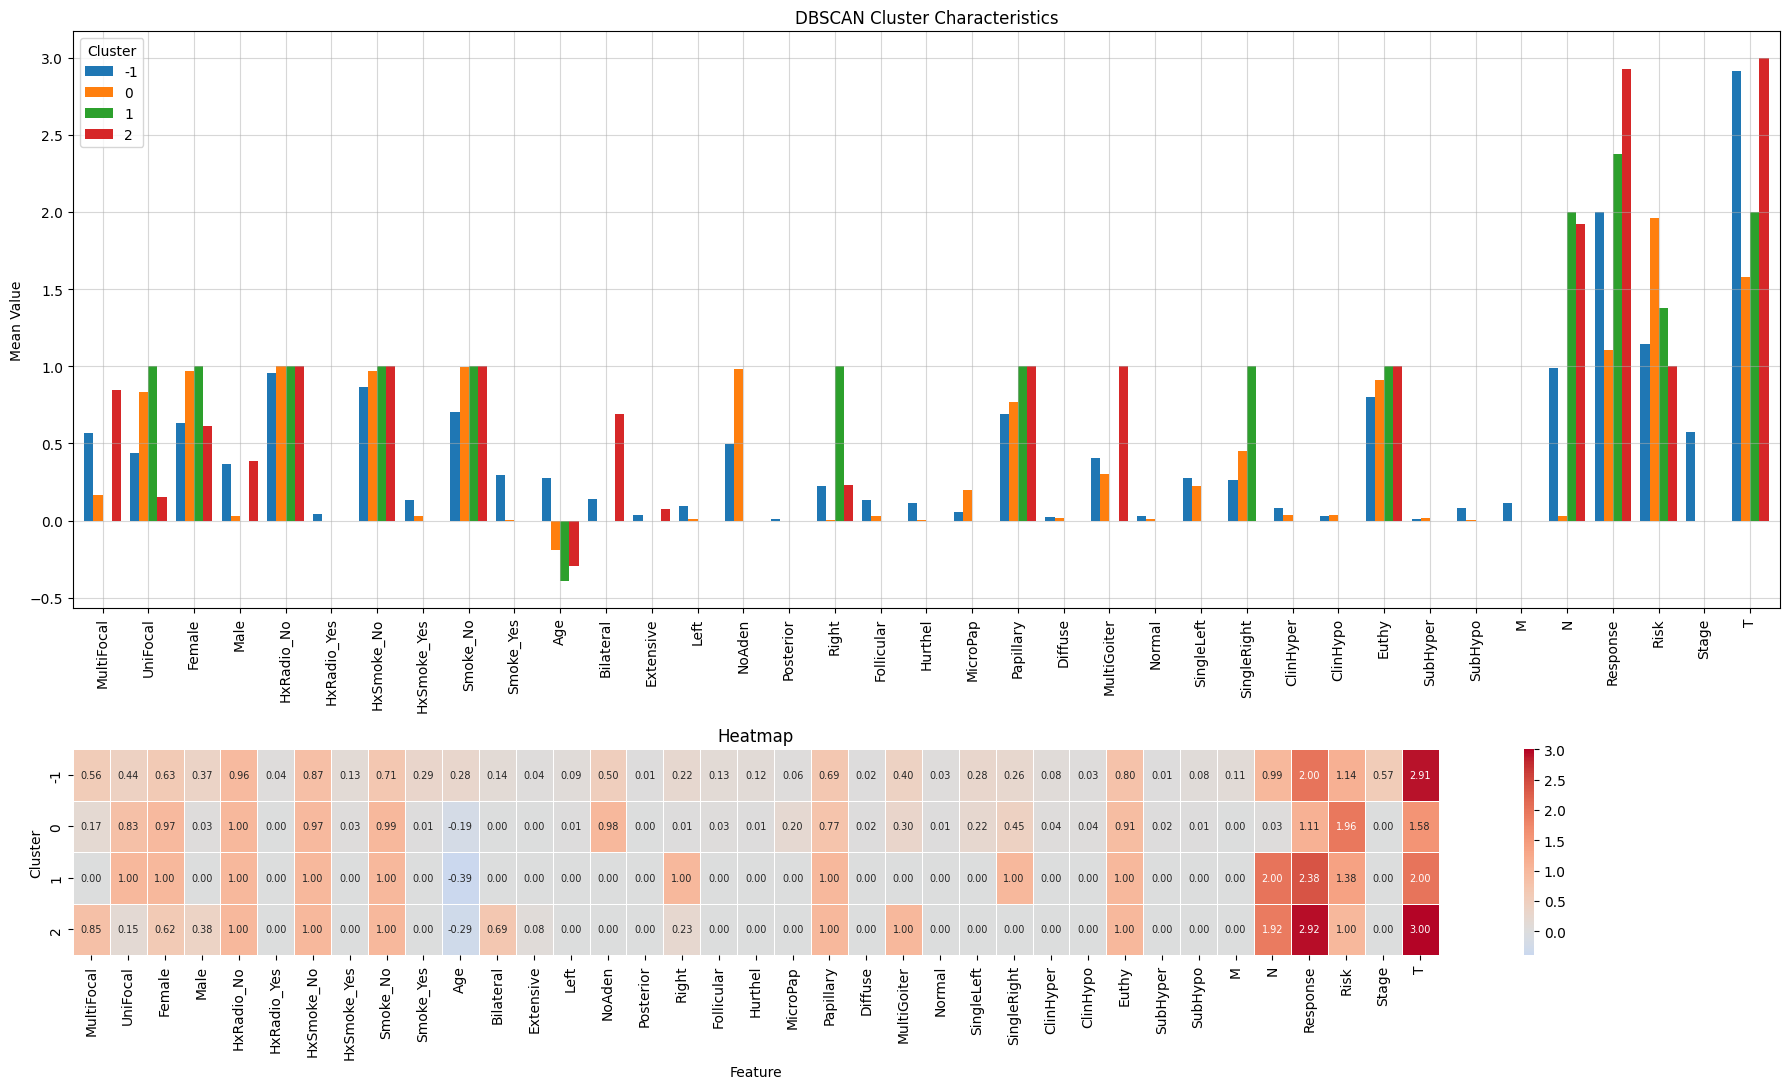

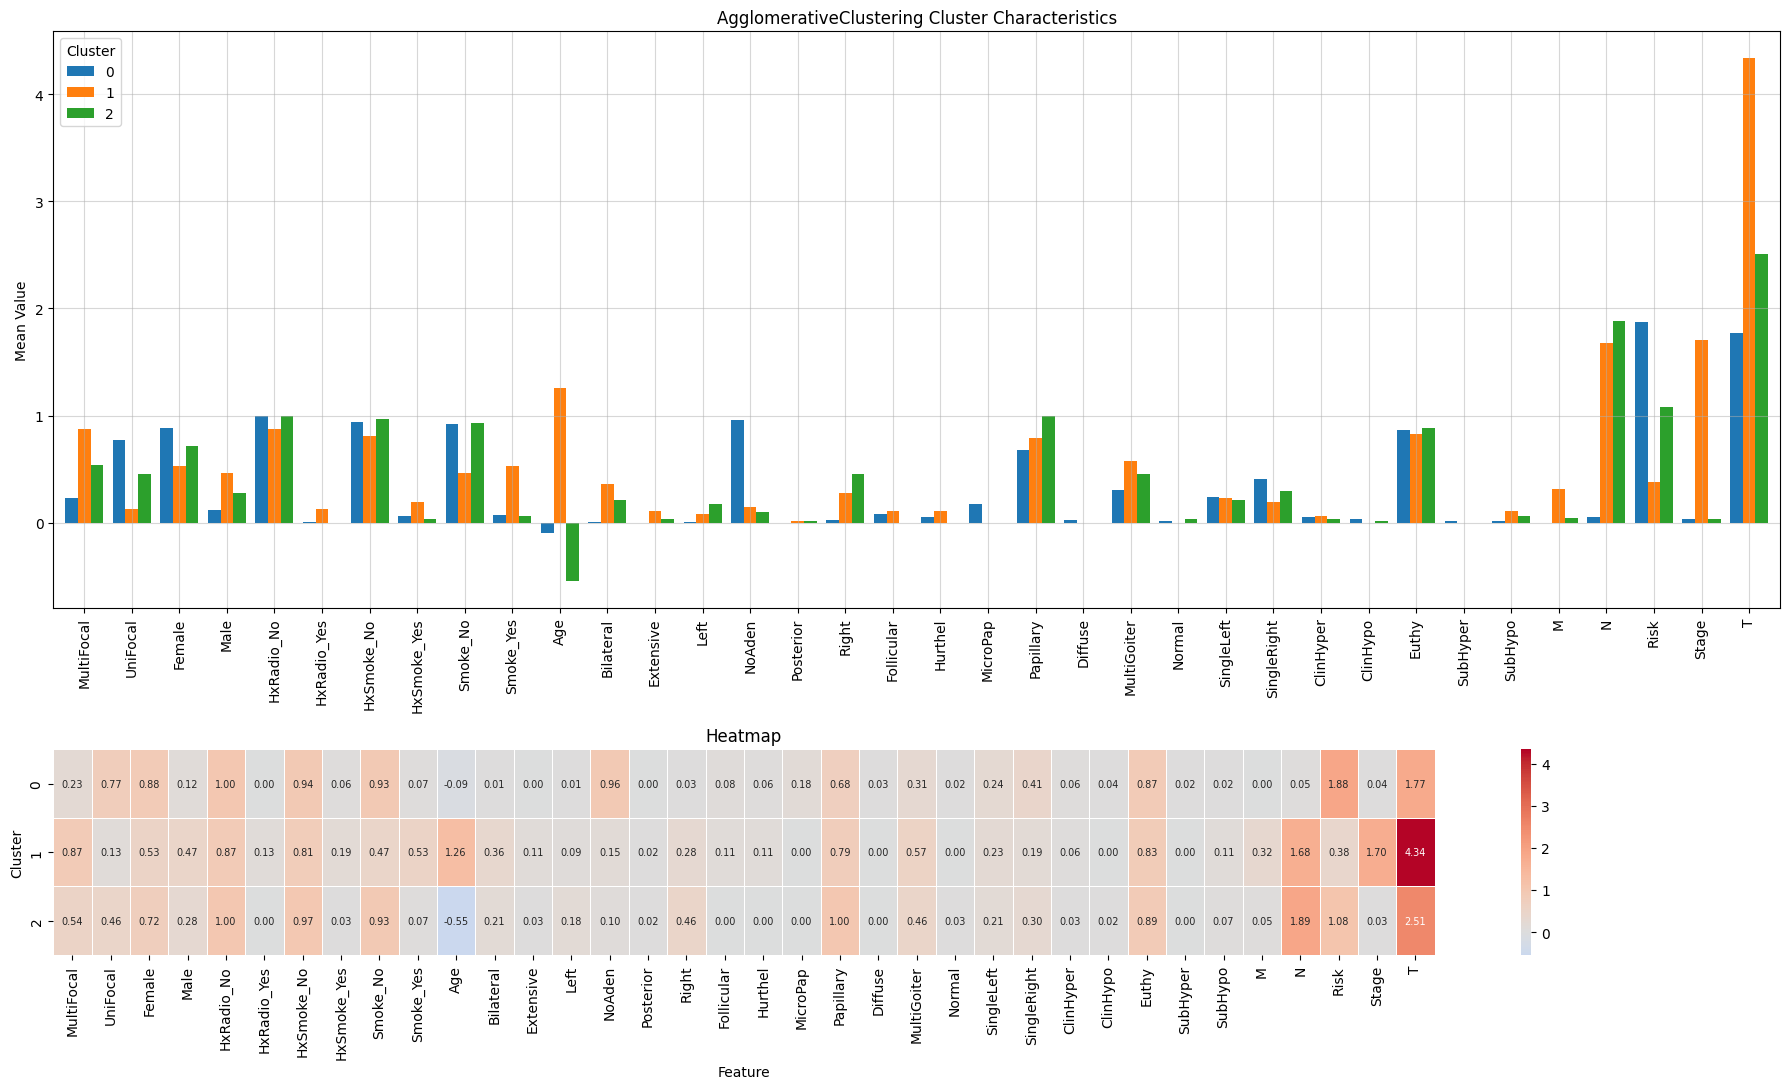

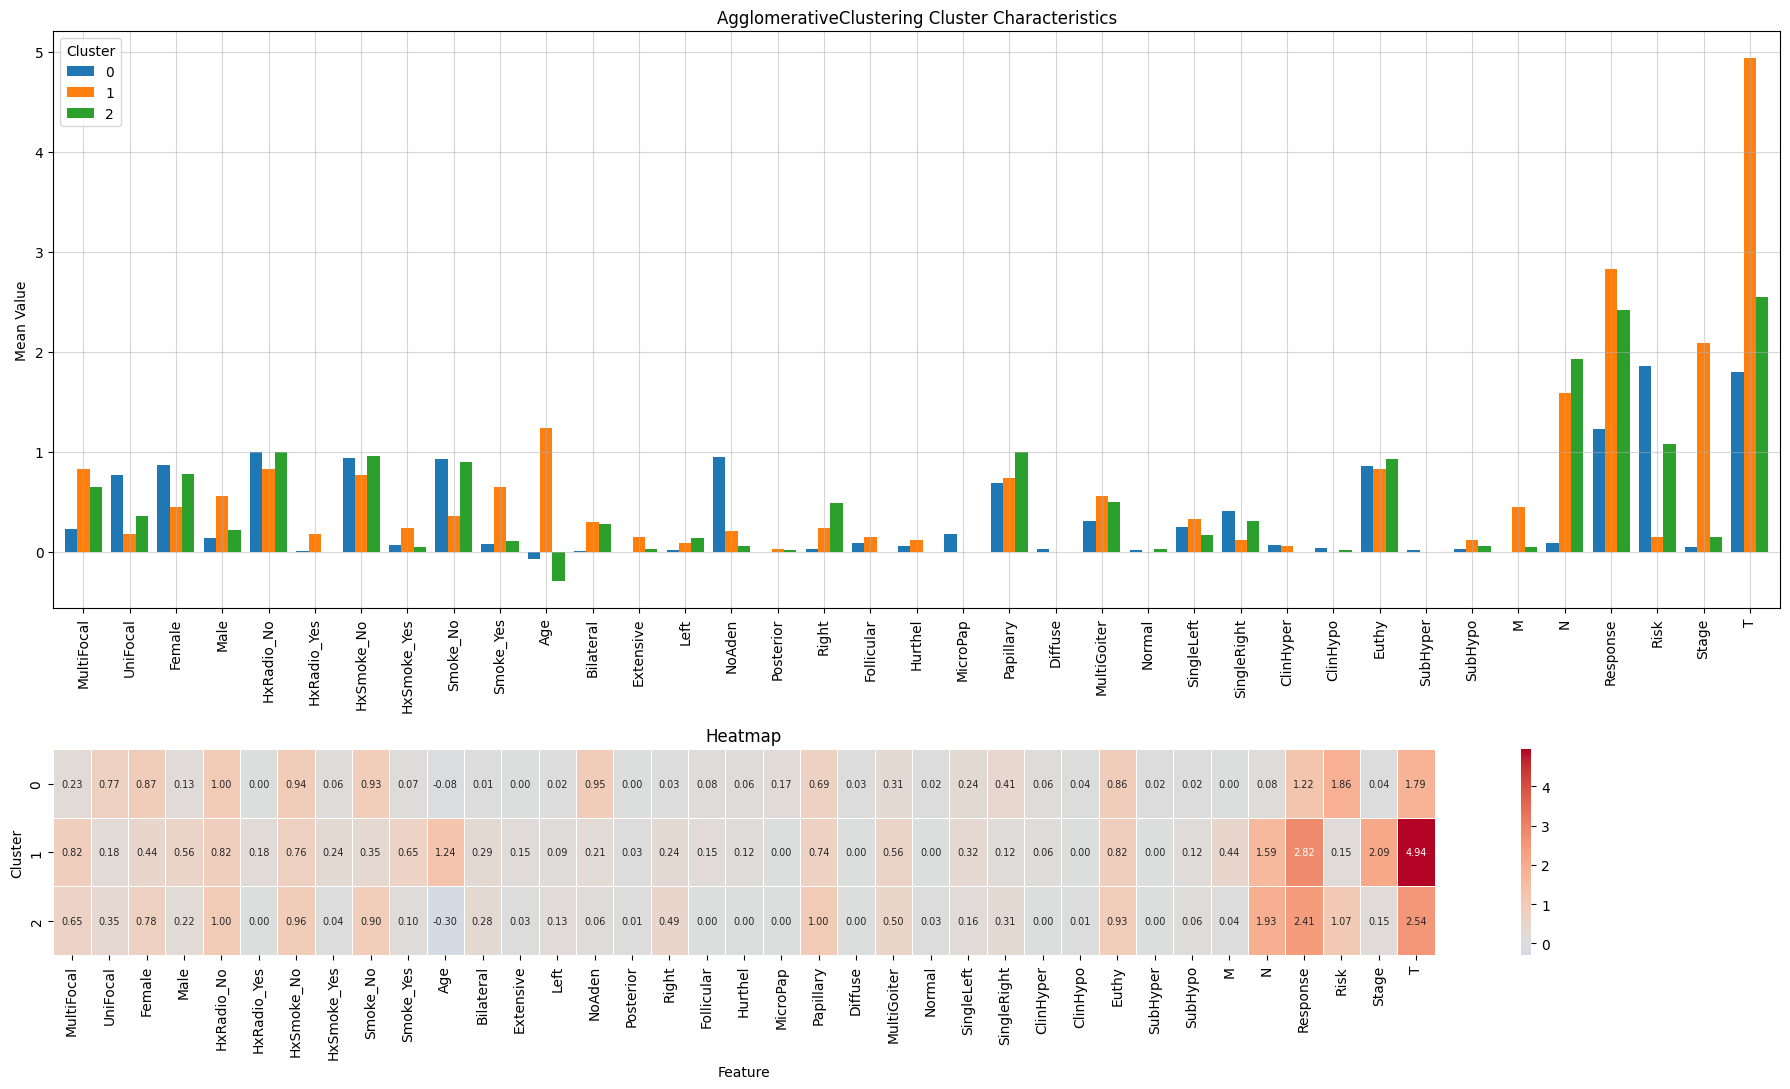

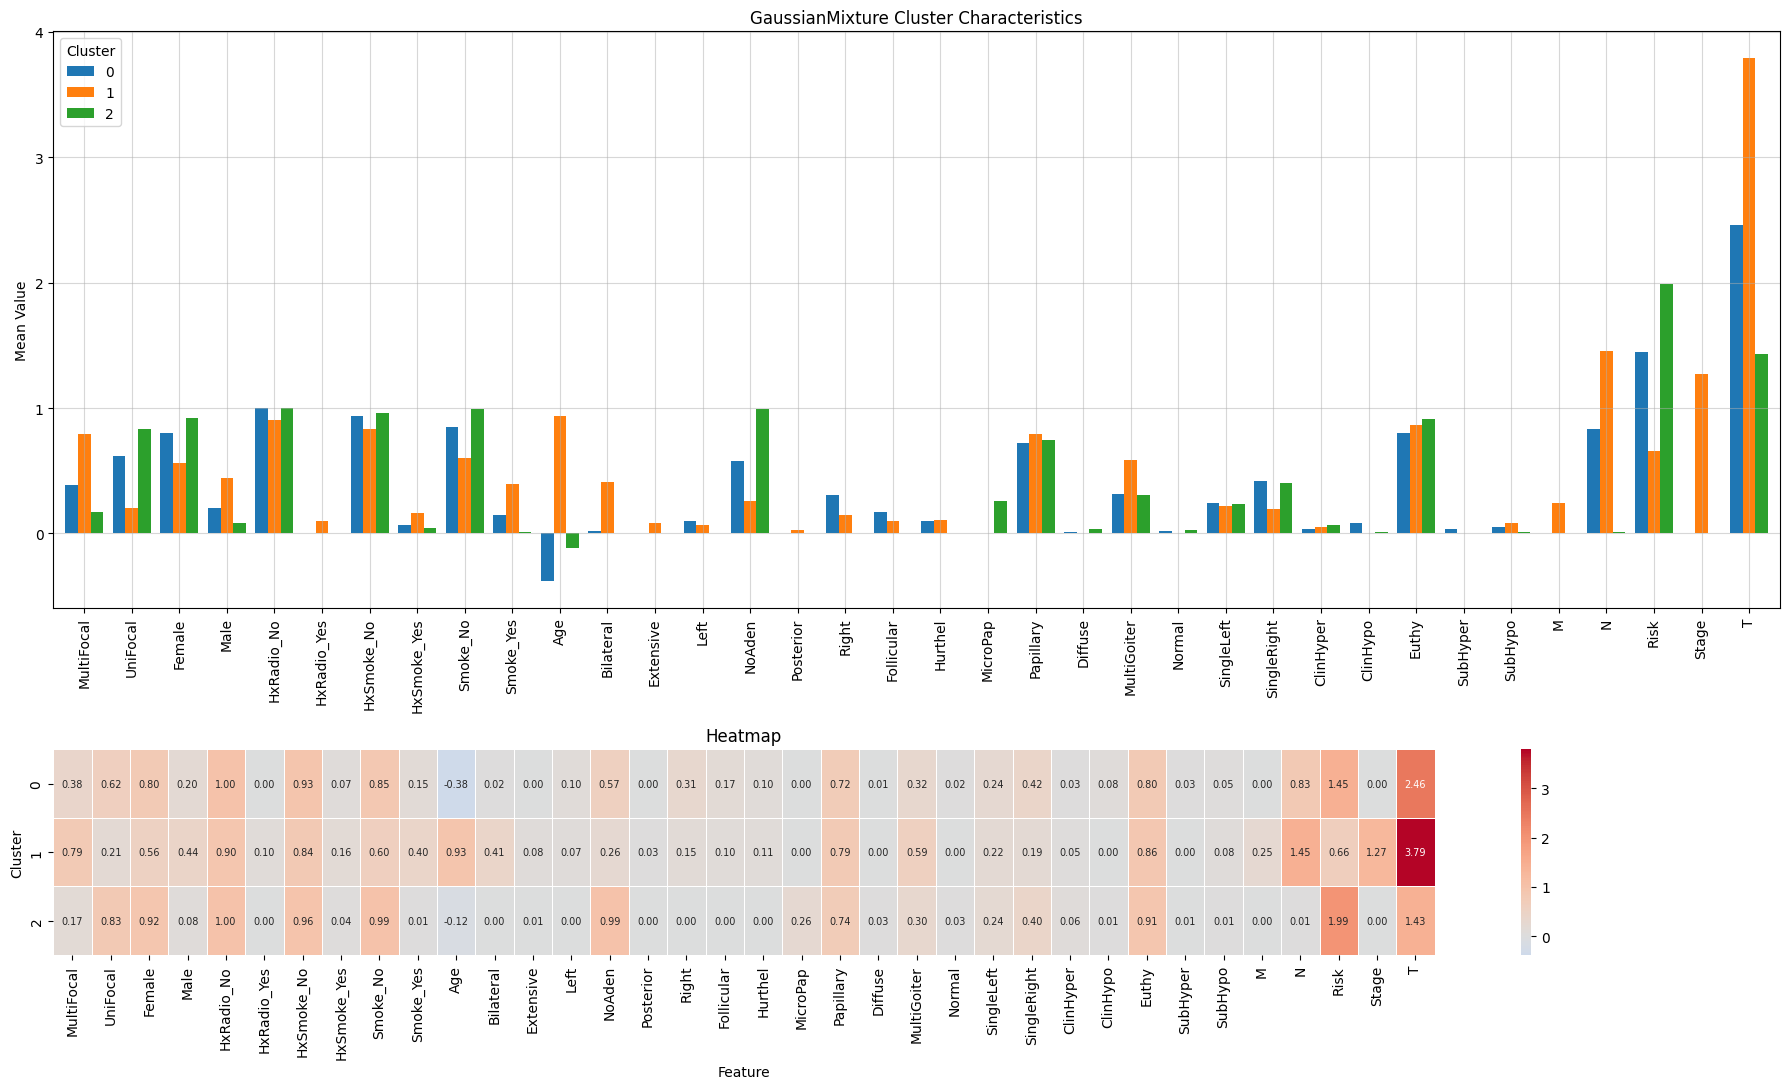

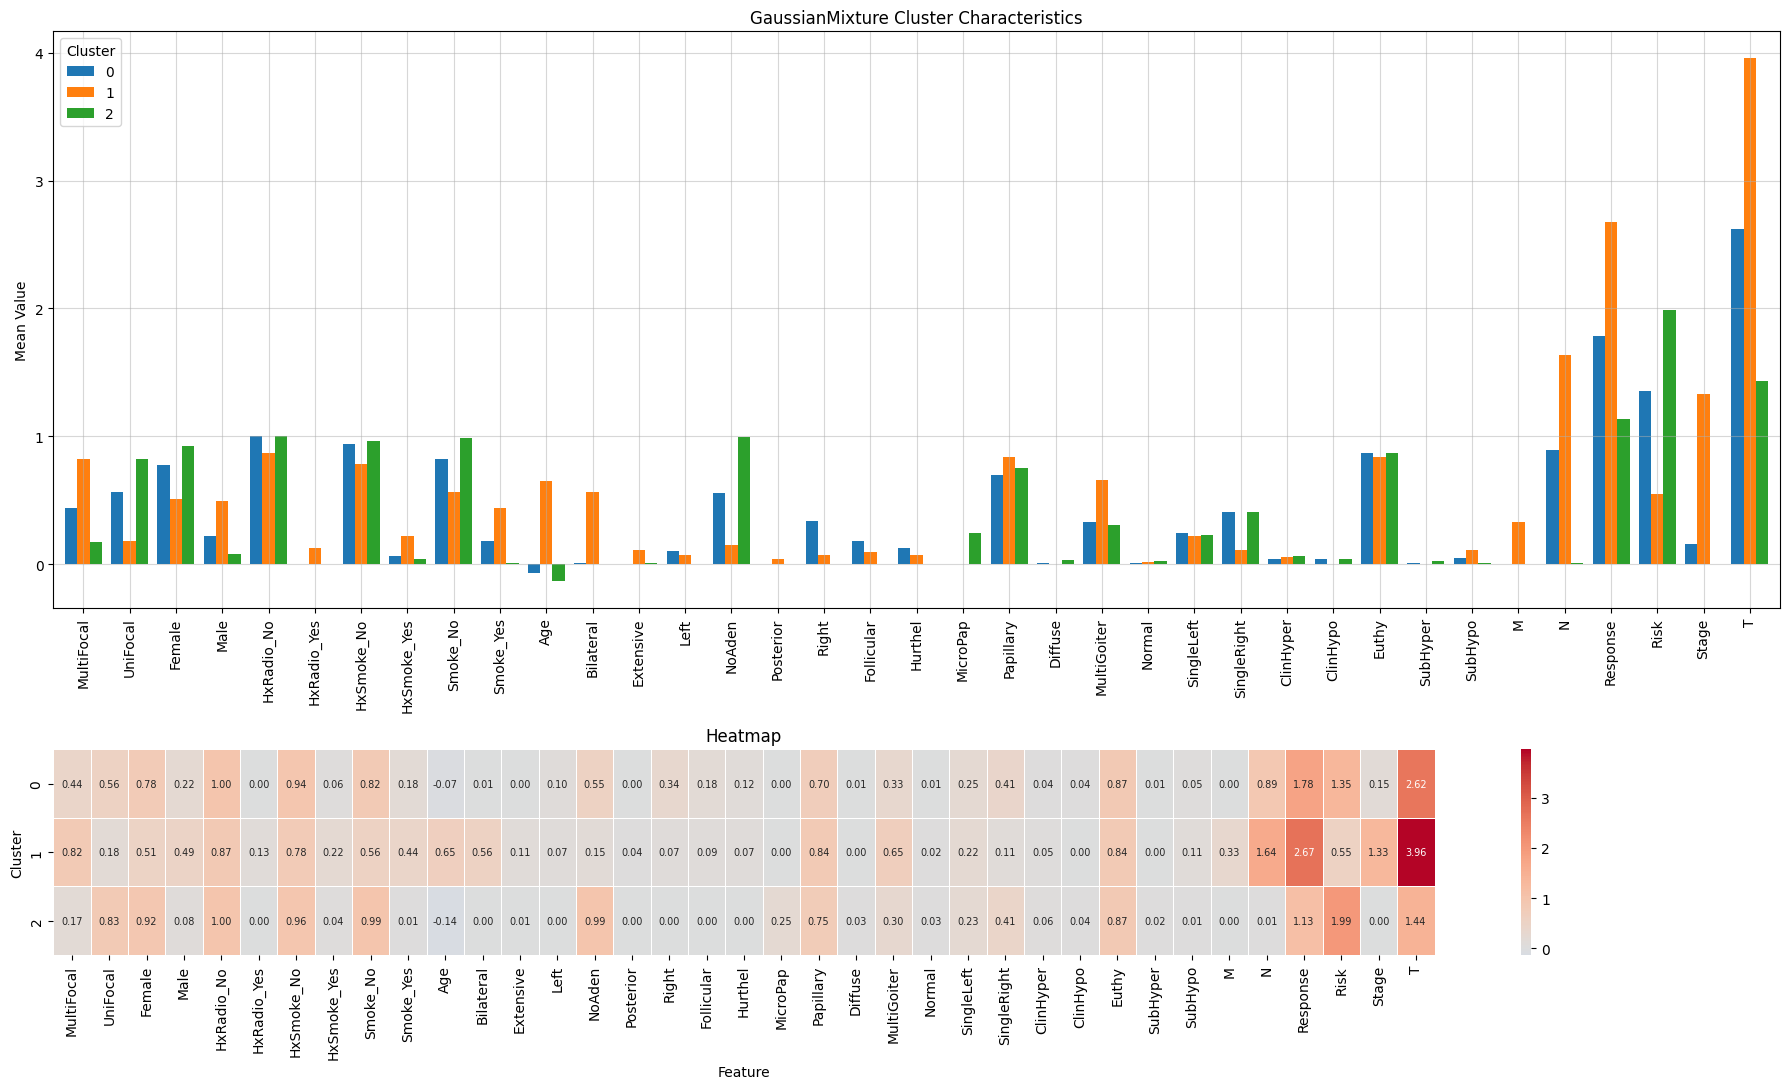

In [23]:
for algo in cluster_char_df["Algorithm"].unique():

    for feature_set in ["A", "B"]:

        cluster_char = clusterChar_per_algo_set(algo, feature_set)

        plot_cluster_char(
            cluster_char,
            algo
        )

In [28]:
def plot_pca(X, clusters, title=""):

    # PCA
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(X)

    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X)

    # Figure
    fig = plt.figure(figsize=(16,6))

    # -------------------------
    # 2D
    # -------------------------
    ax1 = fig.add_subplot(121)

    scatter = ax1.scatter(
        X_pca2[:,0],
        X_pca2[:,1],
        c=clusters,
        cmap="viridis"
    )

    ax1.set_title(
        f"{title} 2 PCs ({pca2.explained_variance_ratio_.sum()*100:.2f}%)"
    )

    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")

    # -------------------------
    # 3D
    # -------------------------
    ax2 = fig.add_subplot(122, projection="3d")

    scatter = ax2.scatter(
        X_pca3[:,0],
        X_pca3[:,1],
        X_pca3[:,2],
        c=clusters,
        cmap="viridis"
    )

    ax2.set_title(
        f"{title} 3 PCs ({pca3.explained_variance_ratio_.sum()*100:.2f}%)"
    )

    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")

    plt.tight_layout()
    plt.show()

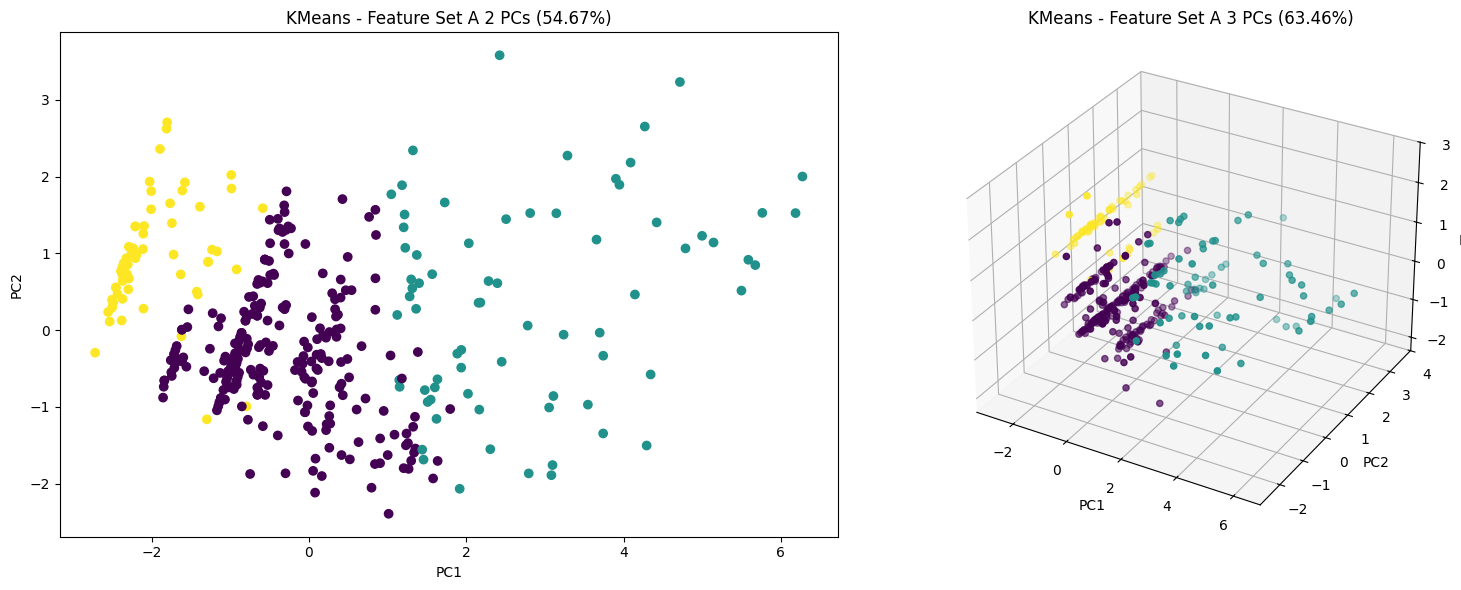

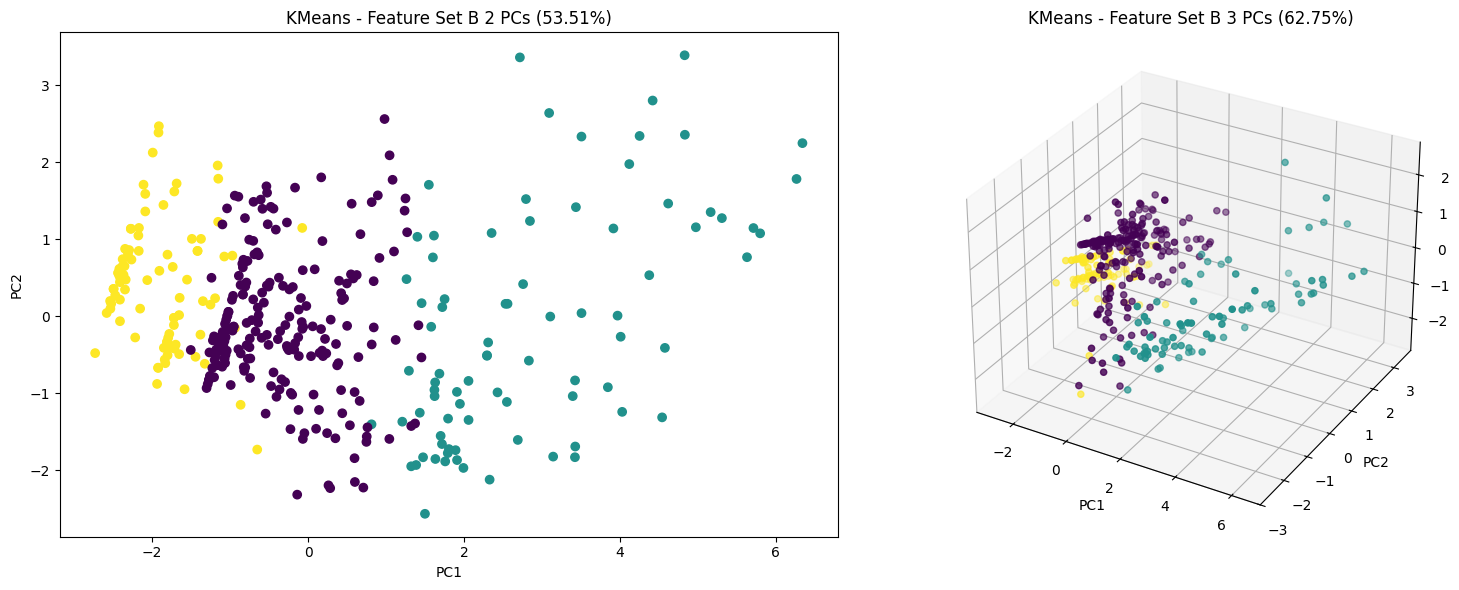

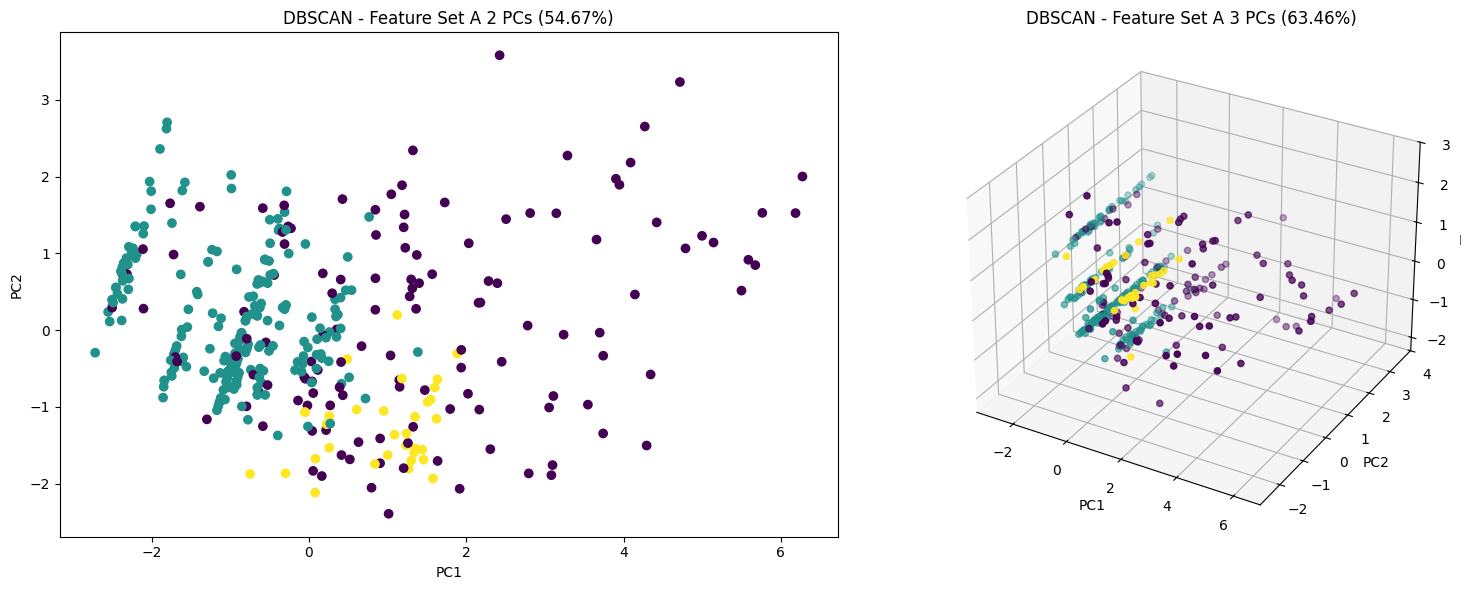

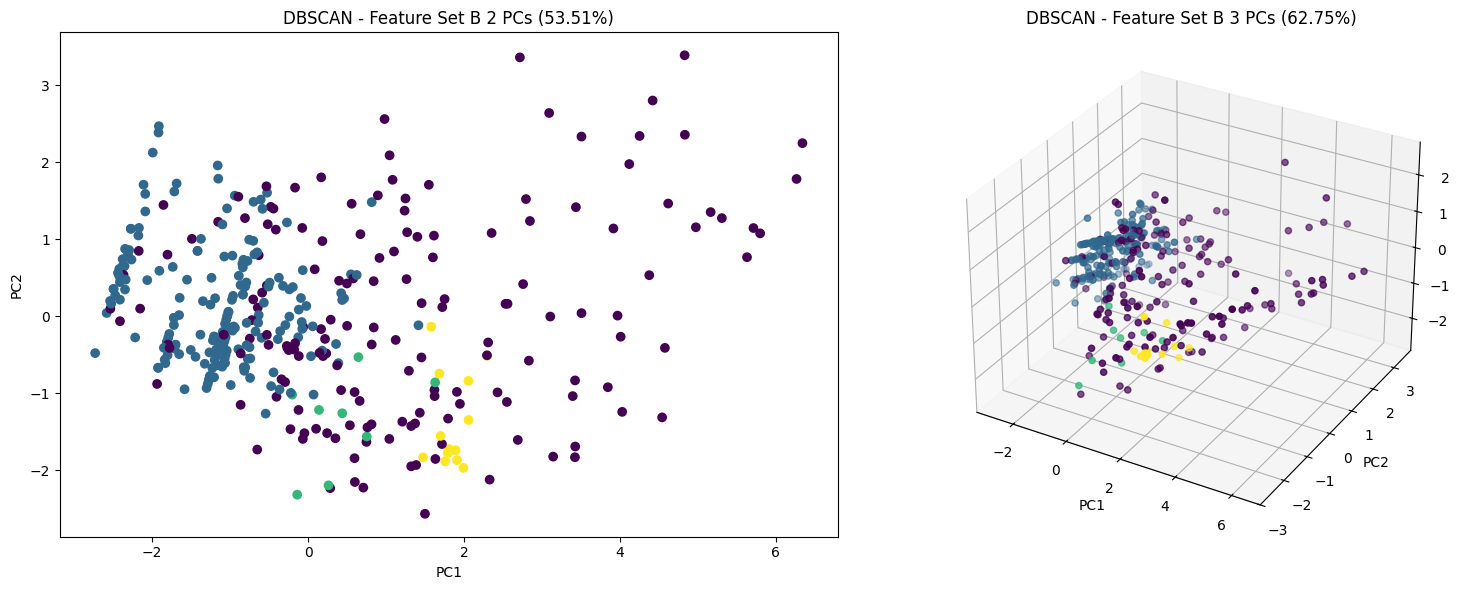

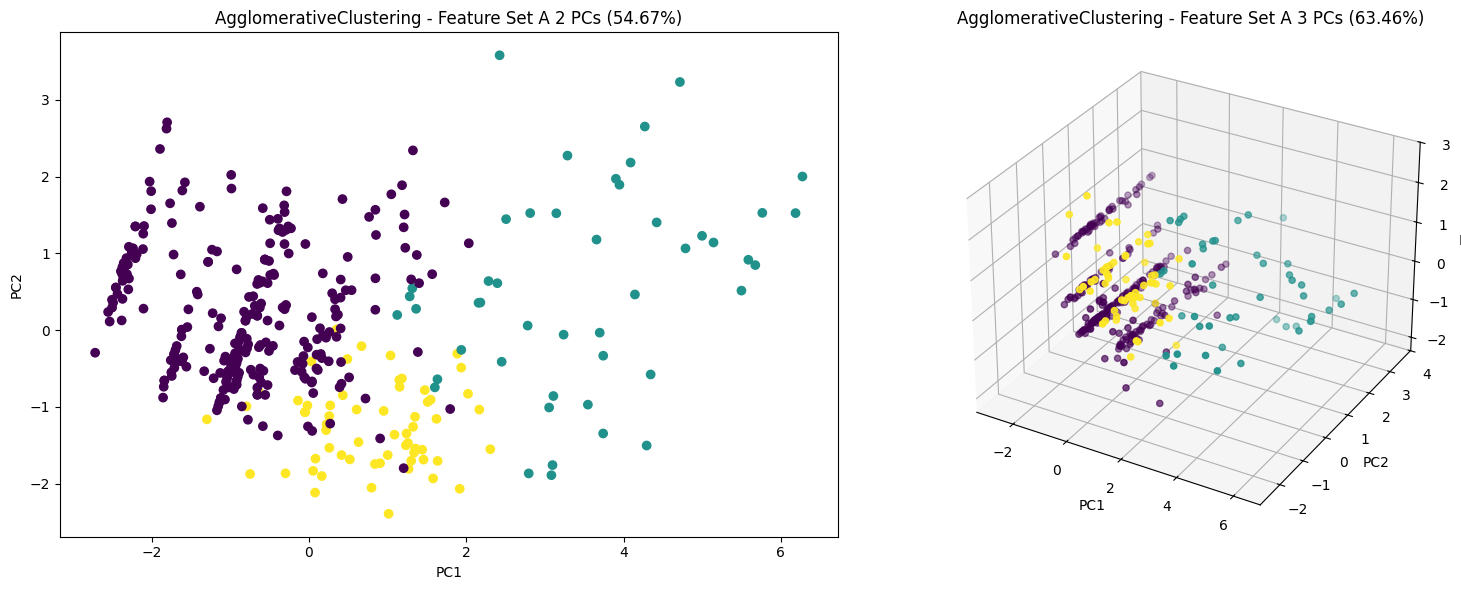

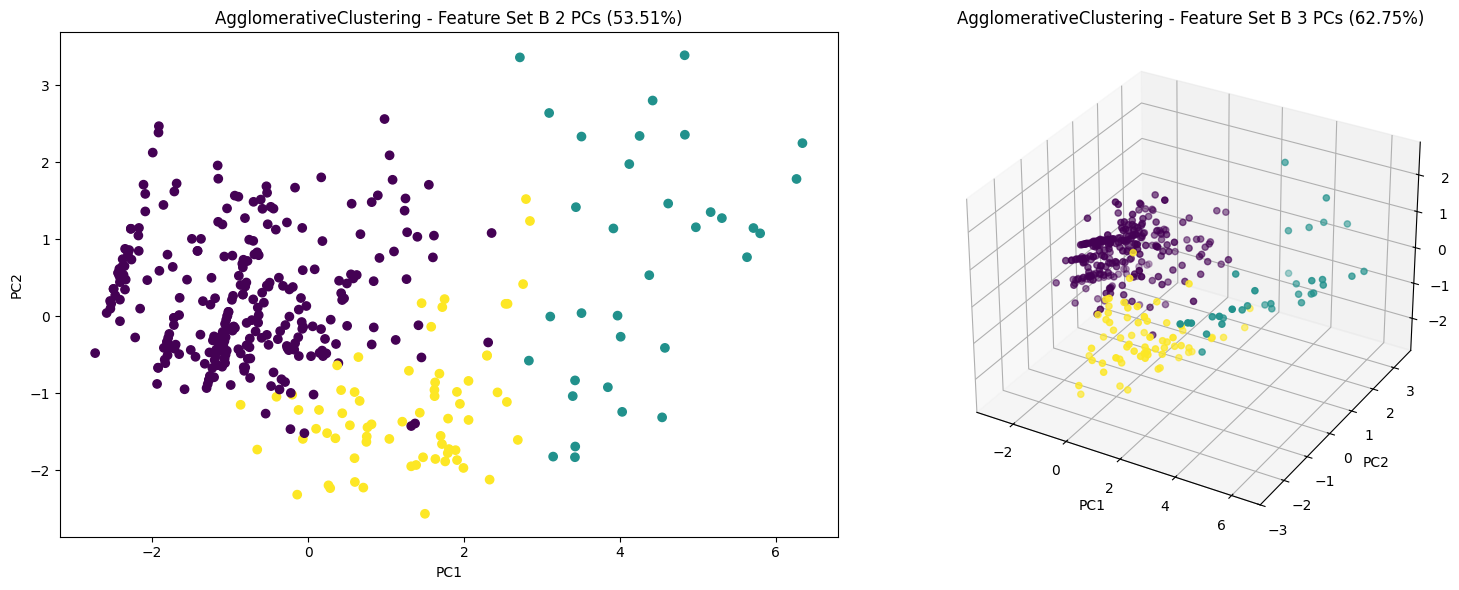

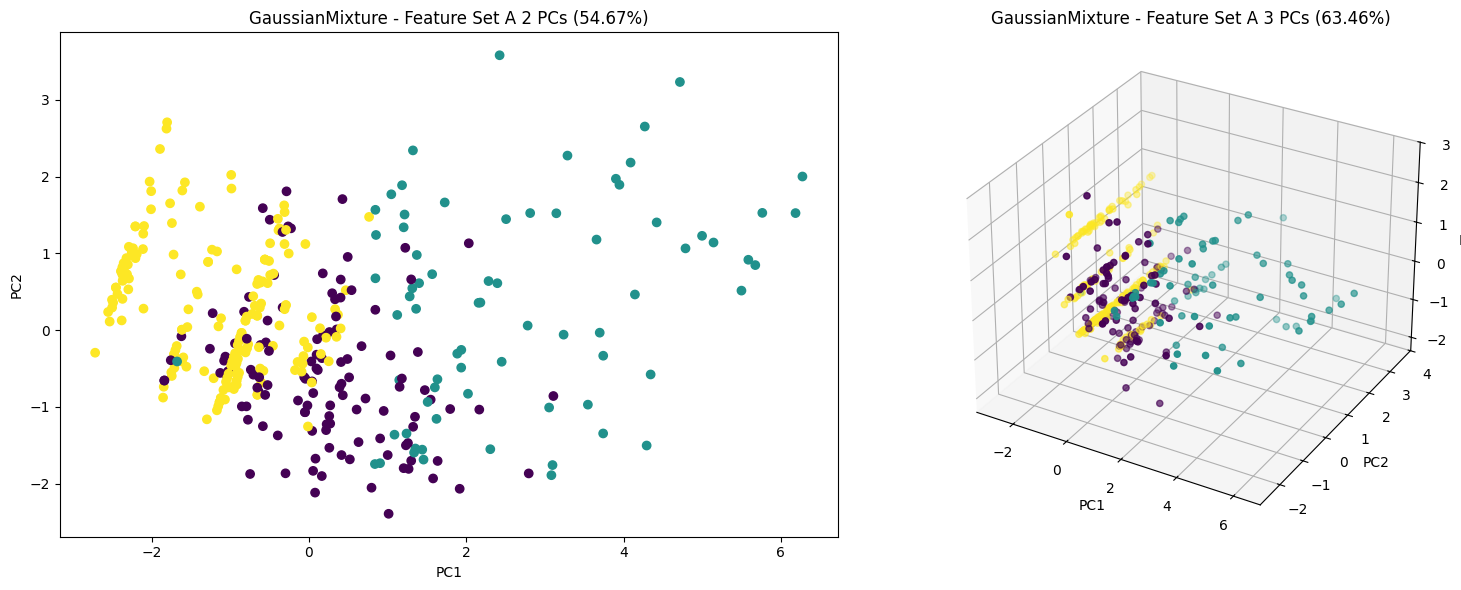

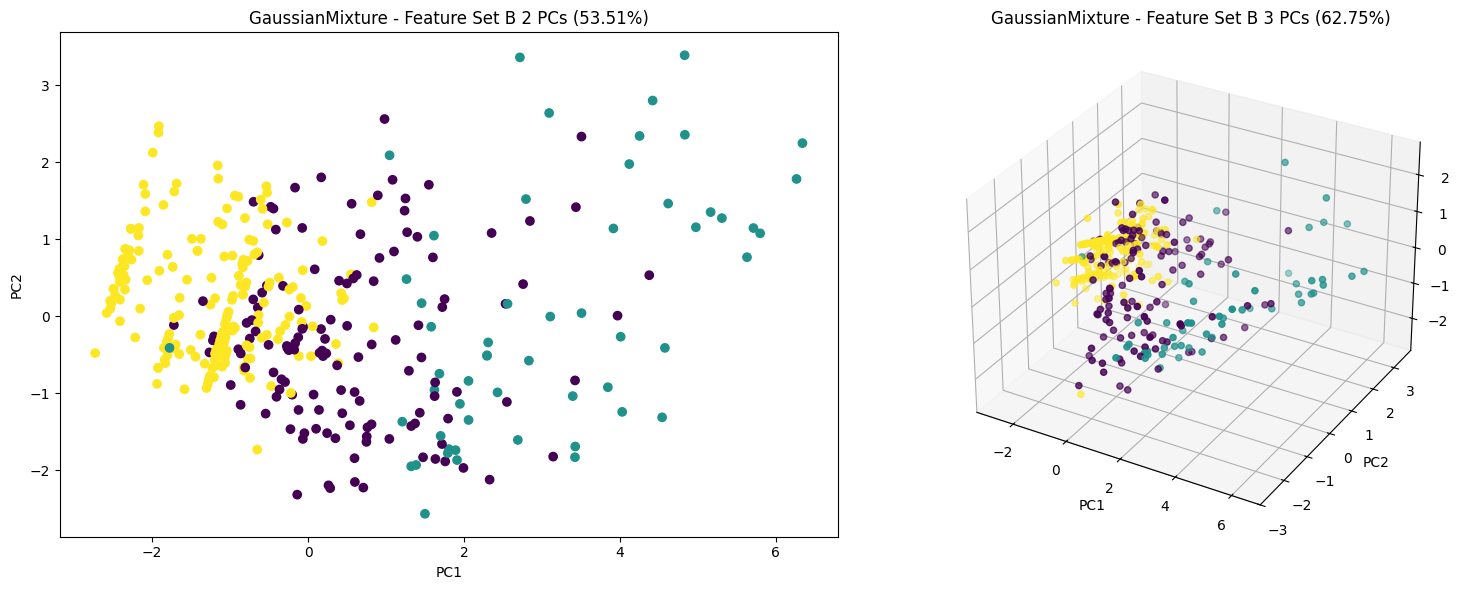

In [29]:
for algo in clt_algo.keys():

    plot_pca(
        X_A,
        X_A_clusters[f"{algo} Clusters"],
        title=f"{algo} - Feature Set A"
    )

    plot_pca(
        X_B,
        X_B_clusters[f"{algo} Clusters"],
        title=f"{algo} - Feature Set B"
    )

In [31]:
# ==========================================================
# Hands-On ML Style Decision Boundary Plot
# ==========================================================

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], "k.", markersize=4)


def plot_centroids(centroids, weights=None,
                   circle_color="white",
                   cross_color="black"):

    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="o",
        s=250,
        linewidths=3,
        color=circle_color,
        edgecolor="black",
        zorder=10,
        alpha=0.9
    )

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=120,
        linewidths=3,
        color=cross_color,
        zorder=11
    )


def plot_decision_boundaries(clusterer,
                             X,
                             resolution=400,
                             show_centroids=True,
                             show_xlabels=True,
                             show_ylabels=True):

    mins = X.min(axis=0) - 0.5
    maxs = X.max(axis=0) + 0.5

    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = clusterer.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        Z,
        cmap="Pastel2",
        alpha=0.8
    )

    plt.contour(
        xx,
        yy,
        Z,
        colors="black",
        linewidths=0.5
    )

    plot_data(X)

    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("PC1")
    else:
        plt.tick_params(labelbottom=False)

    if show_ylabels:
        plt.ylabel("PC2")
    else:
        plt.tick_params(labelleft=False)

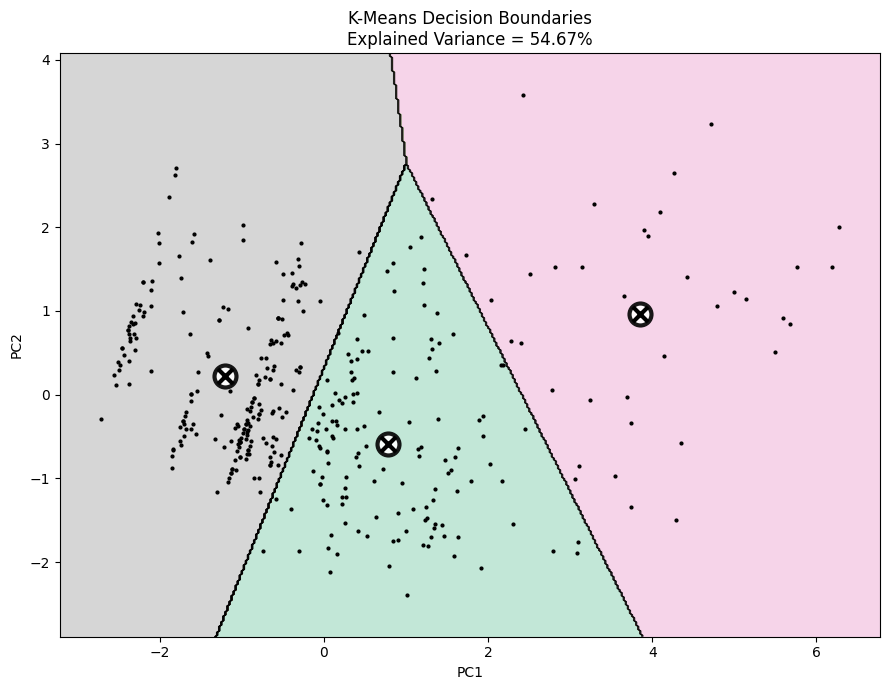

In [32]:
# PCA to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_A)

# Train KMeans on PCA space
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_pca.fit(X_pca)

plt.figure(figsize=(9,7))

plot_decision_boundaries(
    kmeans_pca,
    X_pca
)

plt.title(
    f"K-Means Decision Boundaries\n"
    f"Explained Variance = {pca.explained_variance_ratio_.sum()*100:.2f}%"
)

plt.tight_layout()
plt.show()

In [15]:
pd.crosstab(
    results["Cluster"],
    results["Recurred"],
    normalize="index"
)

Recurred,0,1
Cluster,,
0,0.825203,0.174797
1,0.136986,0.863014
2,0.967213,0.032787
